In [73]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px #
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.metrics import accuracy_score
from termcolor import colored
from sklearn.model_selection import train_test_split, KFold
from sklearn.metrics import confusion_matrix, roc_curve, auc
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt
from IPython.display import display
print(colored("SUCCESSFULLY IMPORTED...", "green", attrs=['reverse']))

SUCCESSFULLY IMPORTED...


In [74]:
vino = pd.read_csv('winequality-red.csv')
vino.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000
mean,8.319637,0.527821,0.270976,2.538806,0.087467,15.874922,46.467792,0.996747,3.311113,0.658149,10.422983,5.636023
std,1.741096,0.179060,0.194801,1.409928,0.047065,10.460157,32.895324,0.001887,0.154386,0.169507,1.065668,0.807569
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000
25%,7.100000,0.390000,0.090000,1.900000,0.070000,7.000000,22.000000,0.995600,3.210000,0.550000,9.500000,5.000000
50%,7.900000,0.520000,0.260000,2.200000,0.079000,14.000000,38.000000,0.996750,3.310000,0.620000,10.200000,6.000000
75%,9.200000,0.640000,0.420000,2.600000,0.090000,21.000000,62.000000,0.997835,3.400000,0.730000,11.100000,6.000000
max,15.900000,1.580000,1.000000,15.500000,0.611000,72.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000


In [75]:
vino.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB


In [76]:
print(vino.shape)


(1599, 12)


In [77]:
print("The shape of the dataset=",vino.shape)

nrow, ncols = vino.shape
nf = ncols - 1
totdata = nrow * ncols

print(f"total number of Rows: {nrow}")
print(f"total number of Columns: {ncols}")
print(f"total number of Features: {nf}")
print(f"total data: {totdata}")

The shape of the dataset= (1599, 12)
total number of Rows: 1599
total number of Columns: 12
total number of Features: 11
total data: 19188


In [78]:
#Displaying the first 10 rows.
dataset_rows = vino.head(10)
print(colored('As you can see, the first 7 rows in the dataset:\n', 'green', attrs=['reverse']))

# Iterates over each row and displayes them
for index, row in dataset_rows.iterrows():
    print(colored(f"Row {index + 1}:",attrs=['reverse']))
    print(row)
    print("-----------------x--------------------")

As you can see, the first 7 rows in the dataset:

Row 1:
fixed acidity            7.4000
volatile acidity         0.7000
citric acid              0.0000
residual sugar           1.9000
chlorides                0.0760
free sulfur dioxide     11.0000
total sulfur dioxide    34.0000
density                  0.9978
pH                       3.5100
sulphates                0.5600
alcohol                  9.4000
quality                  5.0000
Name: 0, dtype: float64
-----------------x--------------------
Row 2:
fixed acidity            7.8000
volatile acidity         0.8800
citric acid              0.0000
residual sugar           2.6000
chlorides                0.0980
free sulfur dioxide     25.0000
total sulfur dioxide    67.0000
density                  0.9968
pH                       3.2000
sulphates                0.6800
alcohol                  9.8000
quality                  5.0000
Name: 1, dtype: float64
-----------------x--------------------
Row 3:
fixed acidity            7.800
vola

In [79]:
print(vino.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB
None


In [80]:
vino.describe().T.round(2)


,count,mean,std,min,25%,50%,75%,max
fixed acidity,1599.0,8.32,1.74,4.60,7.10,7.90,9.20,15.90
volatile acidity,1599.0,0.53,0.18,0.12,0.39,0.52,0.64,1.58
citric acid,1599.0,0.27,0.19,0.00,0.09,0.26,0.42,1.00
residual sugar,1599.0,2.54,1.41,0.90,1.90,2.20,2.60,15.50
chlorides,1599.0,0.09,0.05,0.01,0.07,0.08,0.09,0.61
free sulfur dioxide,1599.0,15.87,10.46,1.00,7.00,14.00,21.00,72.00
total sulfur dioxide,1599.0,46.47,32.90,6.00,22.00,38.00,62.00,289.00
density,1599.0,1.00,0.00,0.99,1.00,1.00,1.00,1.00
pH,1599.0,3.31,0.15,2.74,3.21,3.31,3.40,4.01
sulphates,1599.0,0.66,0.17,0.33,0.55,0.62,0.73,2.00


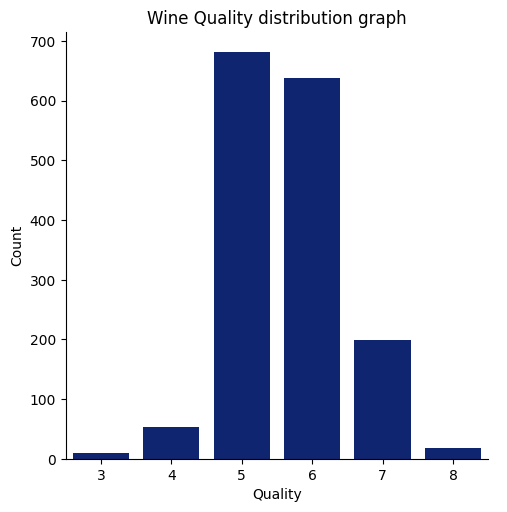

In [81]:
sns.catplot(data=vino, x='quality', kind='count')

plt.title('Wine Quality distribution graph')
plt.xlabel('Quality')
plt.ylabel('Count')
plt.show()

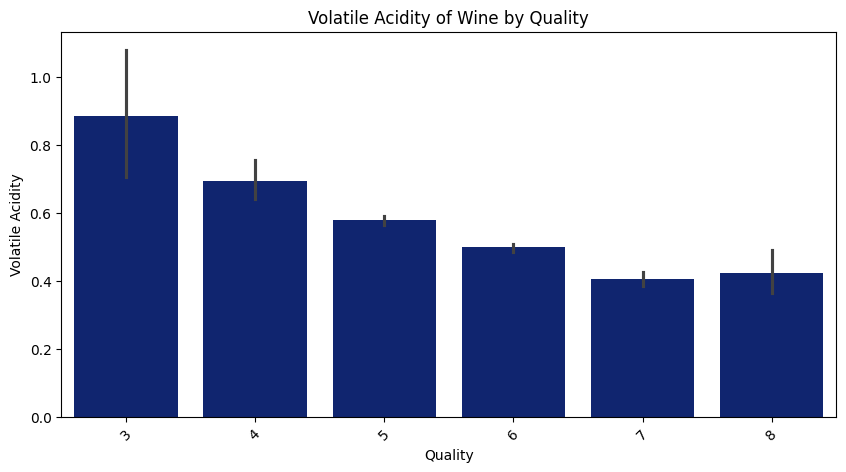

In [82]:
fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(x='quality', y='volatile acidity', data=vino, ax=ax)
#plotting the bar graph for acidity
# Set plot title and axis labels
ax.set_title('Volatile Acidity of Wine by Quality')
ax.set_xlabel('Quality')
ax.set_ylabel('Volatile Acidity')
sns.set_palette('dark')
plt.xticks(rotation=45)
plt.show()

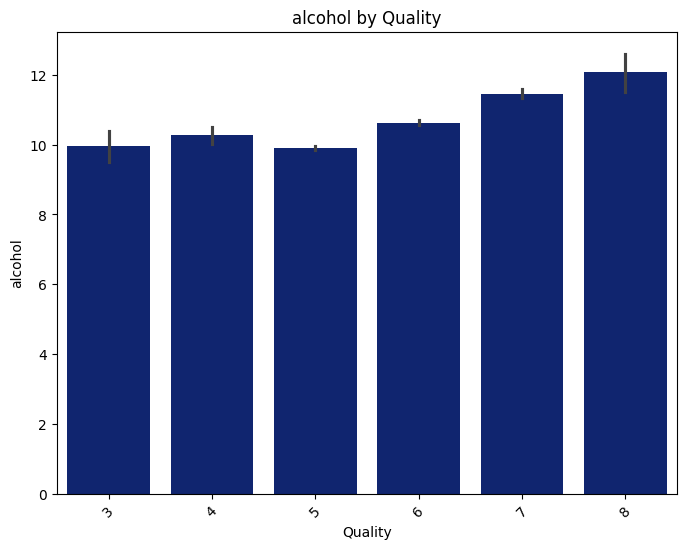

In [83]:
fig, ax = plt.subplots(figsize=(8, 6))
sns.barplot(x='quality', y='alcohol', data=vino, ax=ax)
ax.set_title('alcohol by Quality')
ax.set_xlabel('Quality')
ax.set_ylabel('alcohol')
sns.set_palette('dark')
plt.xticks(rotation=45)
plt.show()

In [84]:
nullC = vino.isnull().sum()
print(nullC)

print(colored(f"Totally, there are {nullC.sum()} null values in the dataset."))

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64
Totally, there are 0 null values in the dataset.


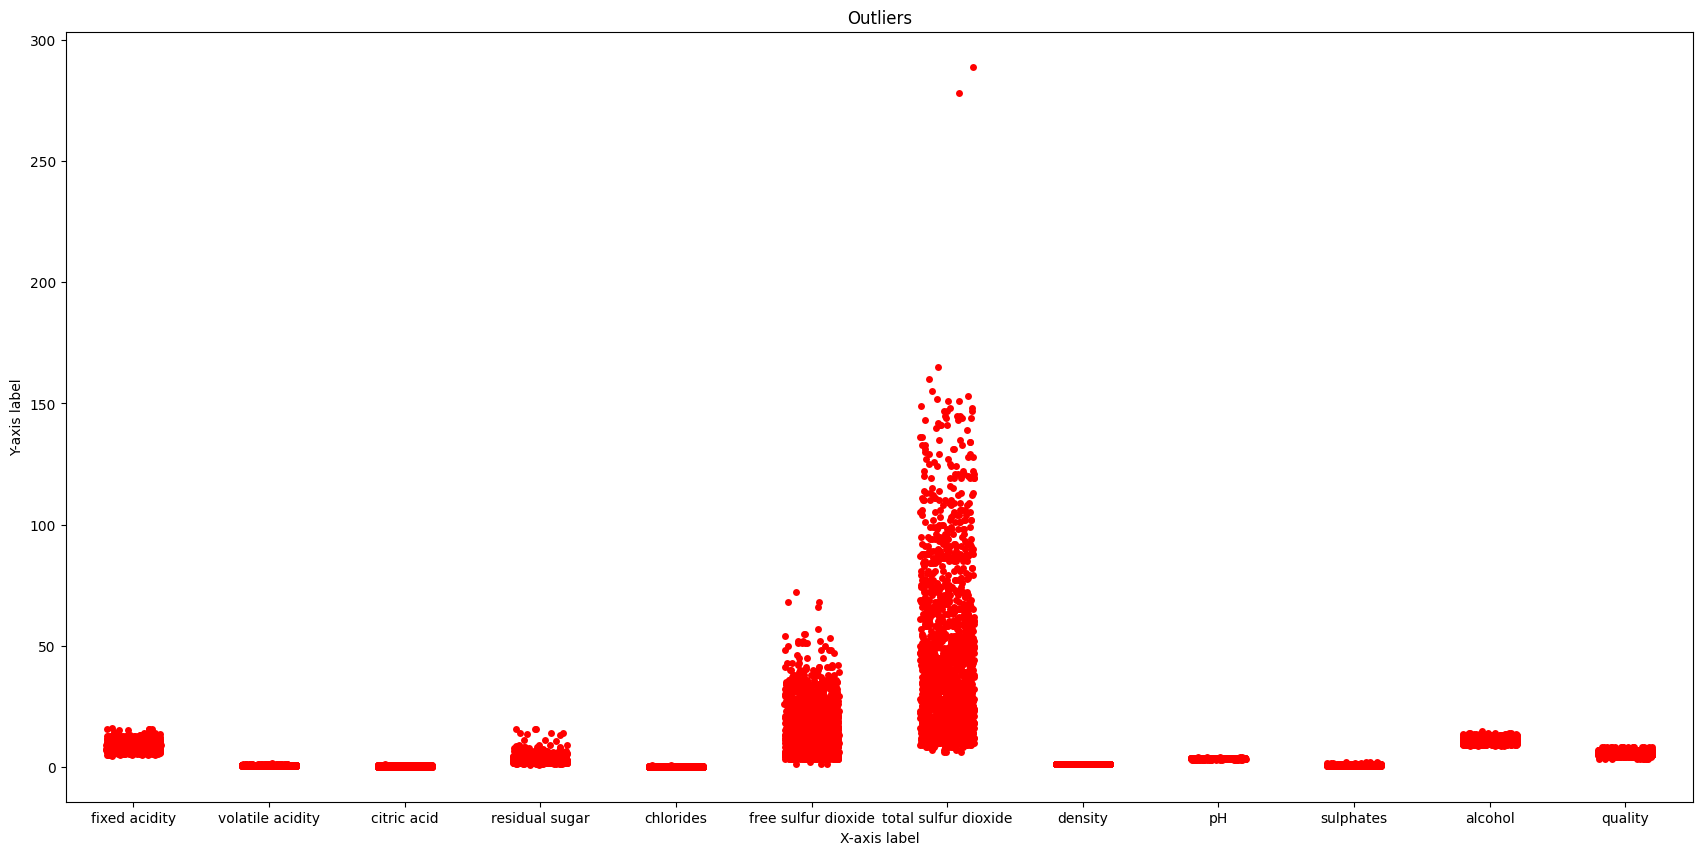

In [85]:
# Graph to represent outliers
plt.figure(figsize=(21, 10))

sns.stripplot(data=vino, color="red", jitter=0.2, size=5)
plt.title("Outliers")
plt.xlabel("X-axis label")
plt.ylabel("Y-axis label")
plt.show()

In [86]:
# Deleting outliers (Removing the number of observation where the total sulfur dioxide is more than 160)

print("Before Removing the outliers", vino.shape)
data = vino[vino['total sulfur dioxide']<160]

#The data after deleting outliers
print("After Removing the outliers", vino.shape)

Before Removing the outliers (1599, 12)
After Removing the outliers (1599, 12)


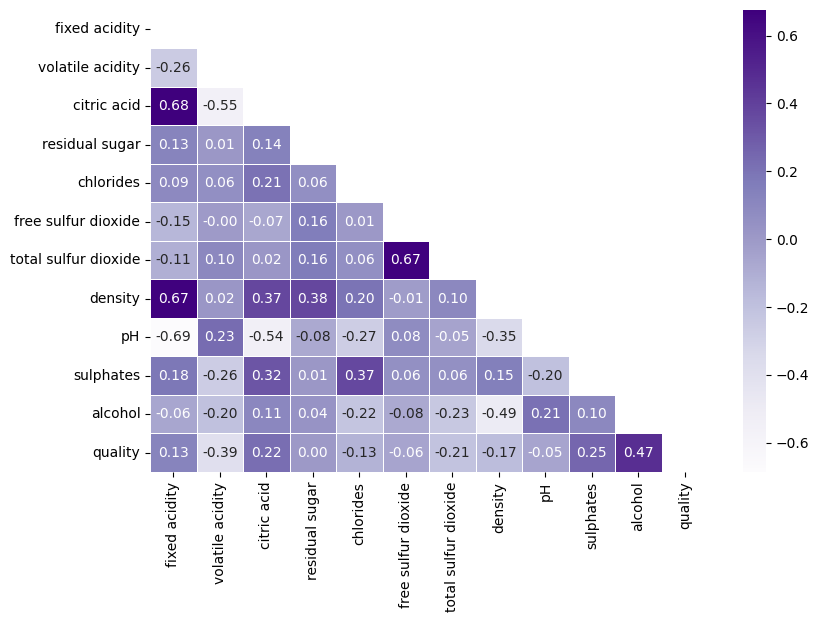

In [87]:
corr = data.corr()
# cmap = sns.diverging_palette(-1, 1, s=100, l=50, n=15, center="dark", as_cmap=True)
plt.figure(figsize=(9, 6))
sns.heatmap(corr, annot=True, fmt='.2f', linewidth=0.5, cmap='Purples', mask=np.triu(corr))
plt.show()

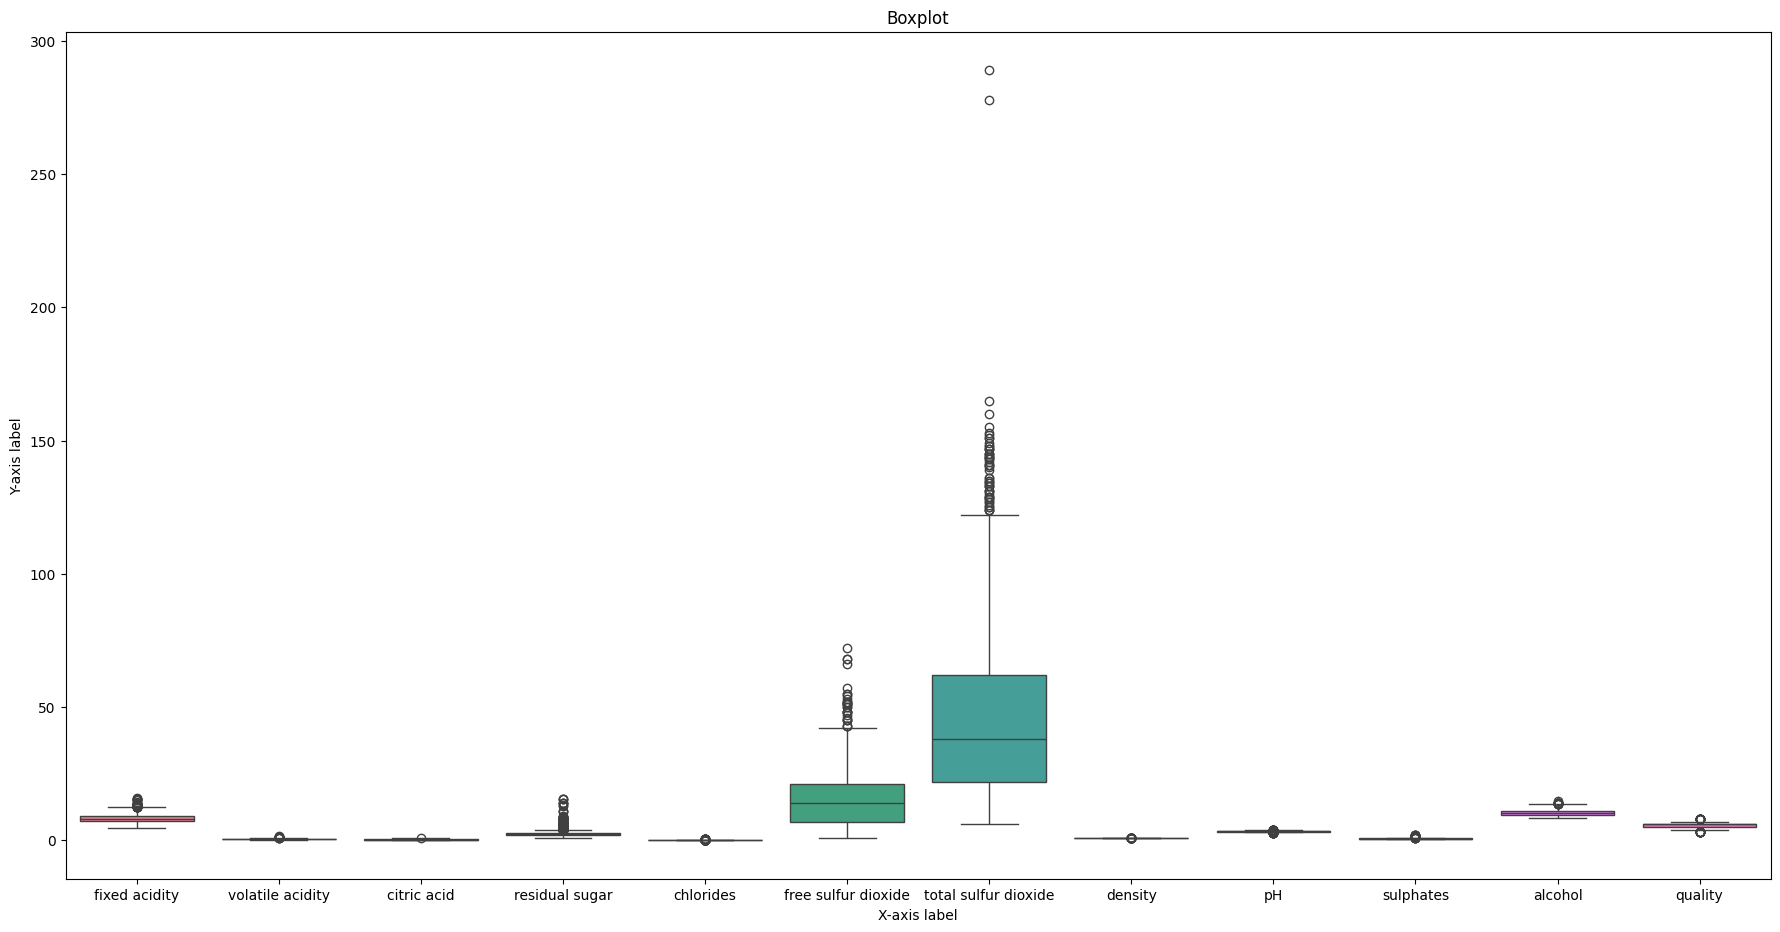

In [88]:
plt.figure(figsize=(22, 11))

sns.boxplot(data=vino)
plt.xlabel("X-axis label")
plt.ylabel("Y-axis label")
plt.title("Boxplot")
plt.show()

In [89]:
# Checking for duplicate entries
duplicate_count = vino.duplicated().sum()
if duplicate_count == 0:
    print(("No duplicate entries found in the dataset."))
else:
    print((f"Number of duplicate entries found: {duplicate_count}"))

Number of duplicate entries found: 240


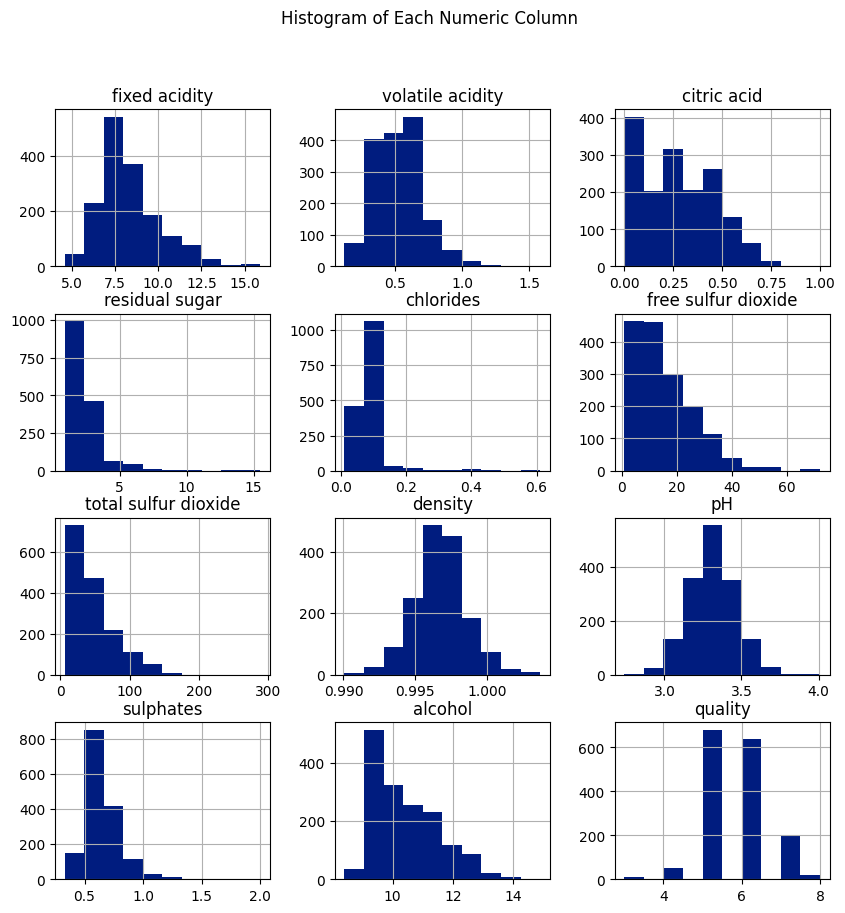

In [90]:
vino.hist(figsize=(10, 10))
plt.suptitle('Histogram of Each Numeric Column')
plt.show()

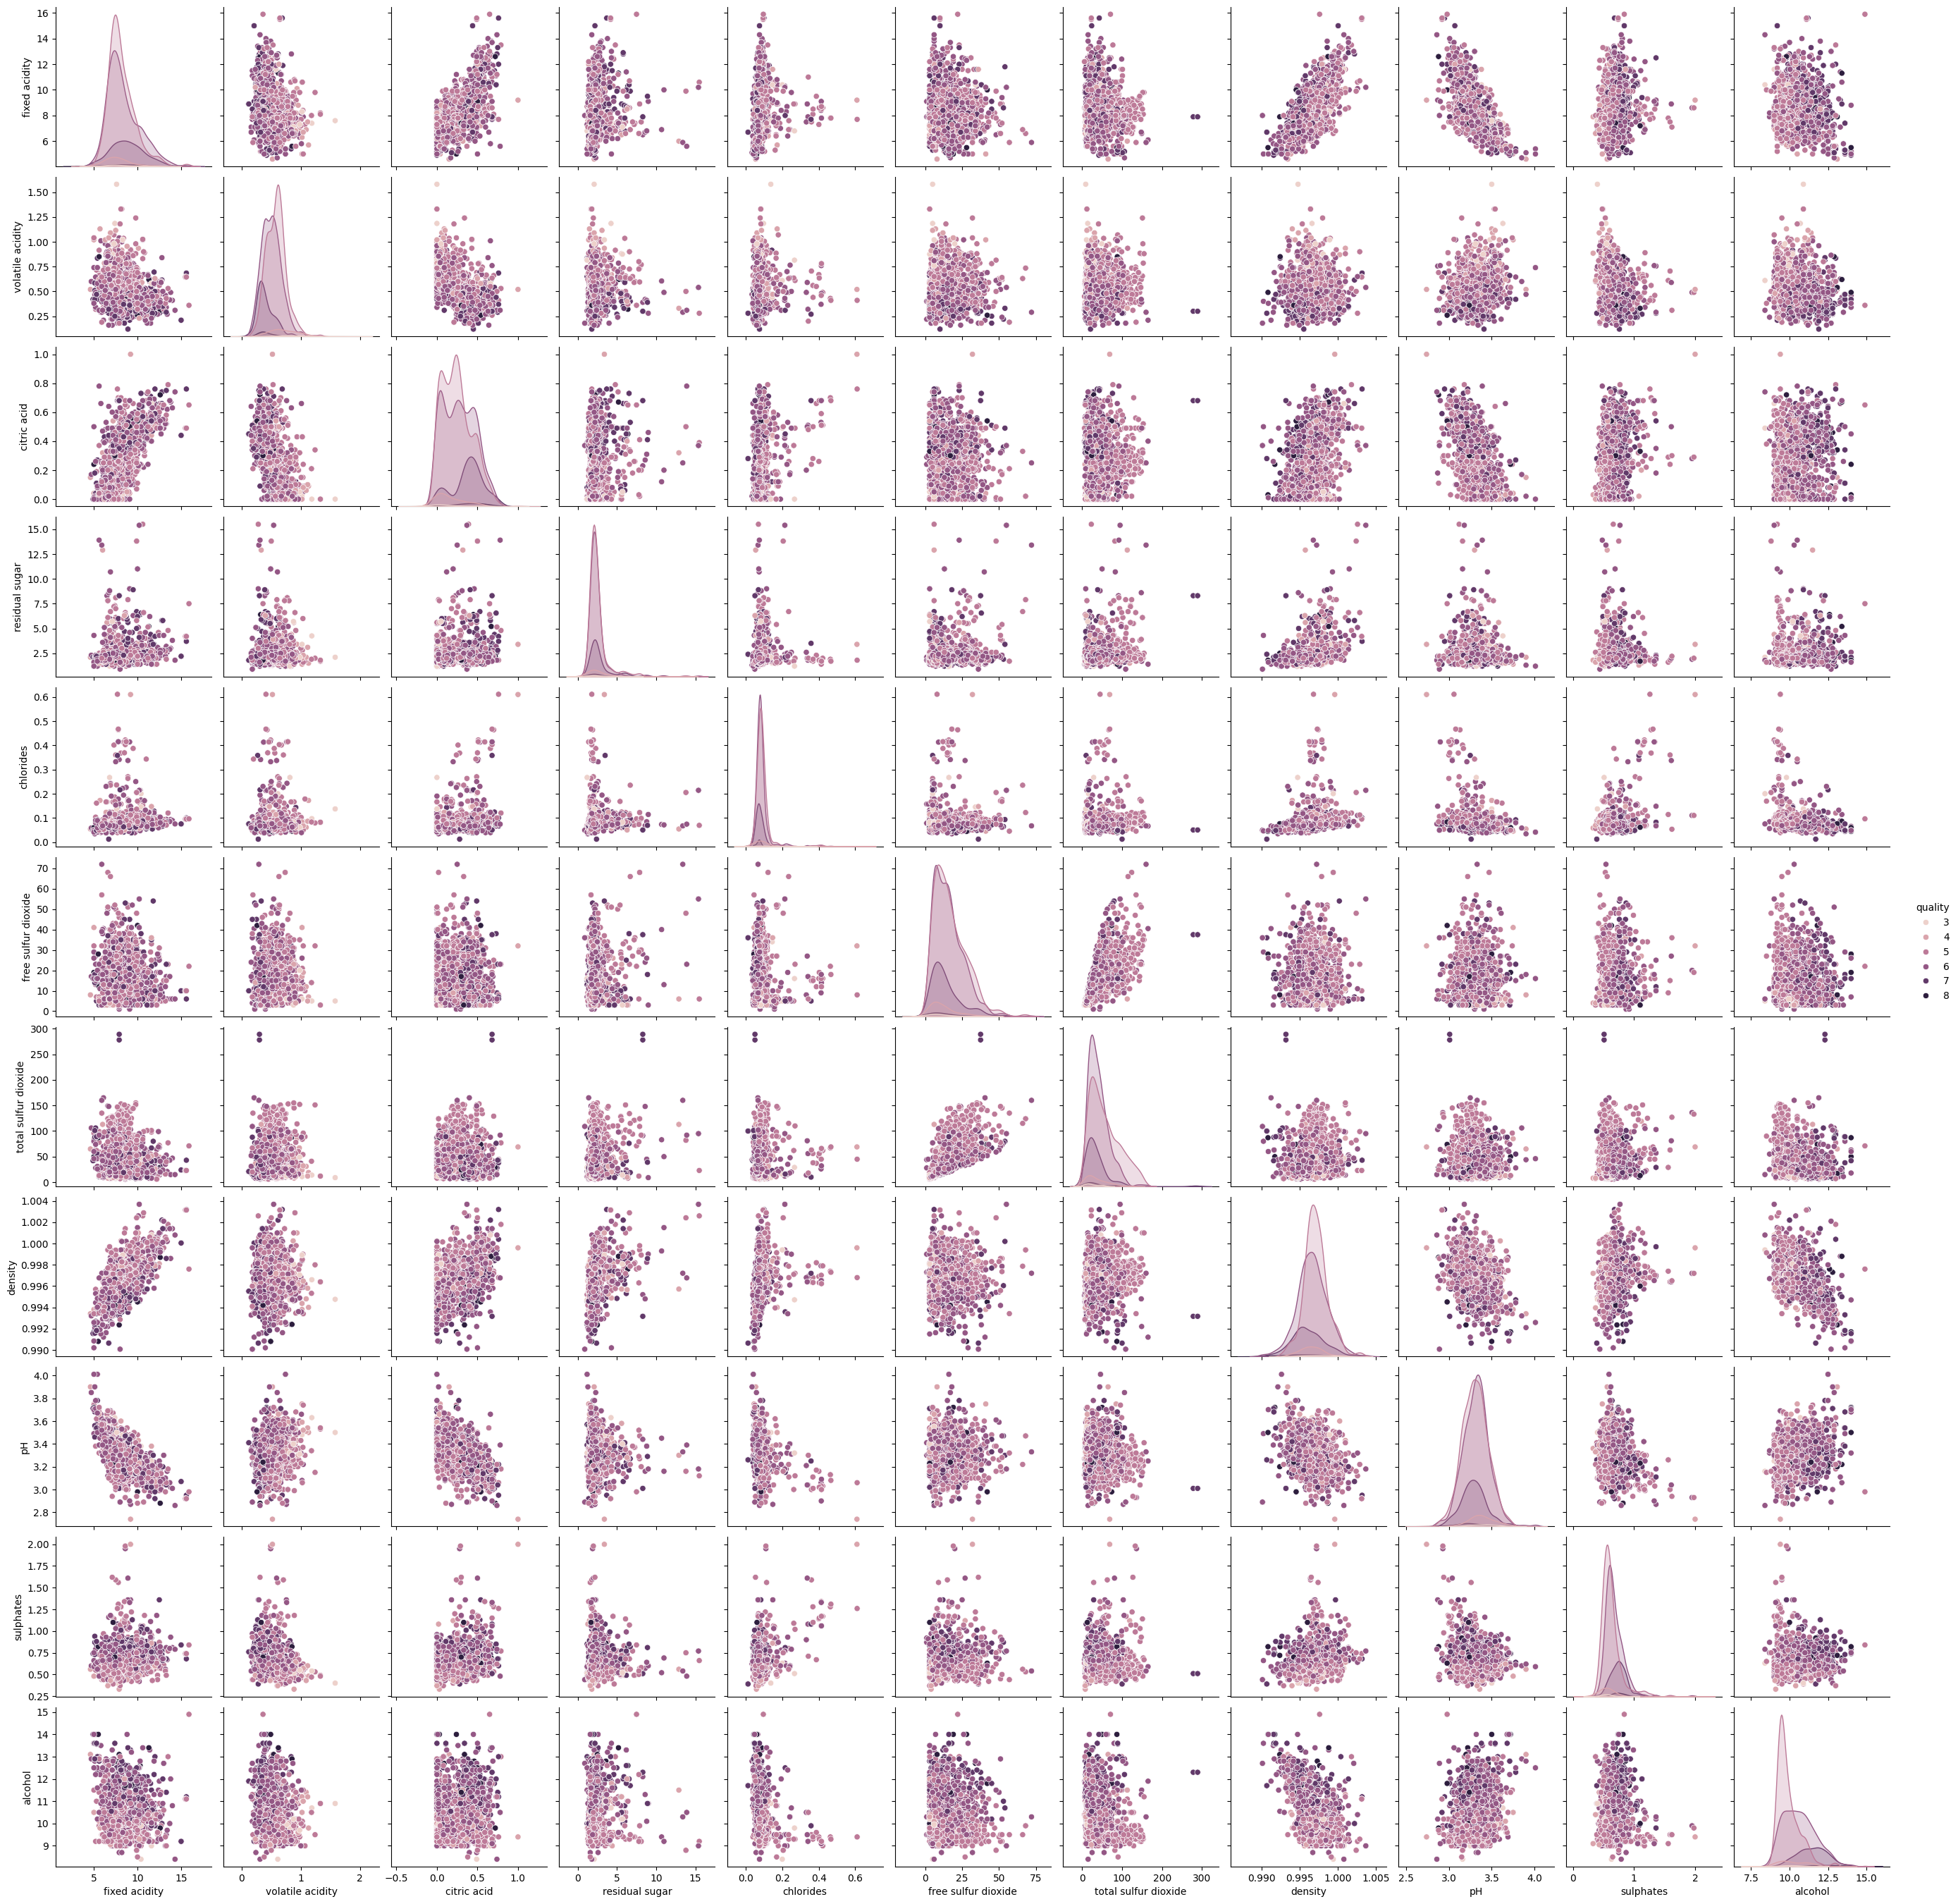

In [91]:
# Plot pairwise relationships in the 'data' DataFrame and color the points based on the 'quality' variable and then display the plot
sns.pairplot(vino, hue="quality")
plt.show()

In [92]:
vino.quality.value_counts()


,count
quality,
5,681
6,638
7,199
4,53
8,18
3,10


/usr/local/lib/python3.10/dist-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step  
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
Random Forest Metrics:


,TP,TN,FP,FN,TPR,TNR,FPR,FNR,Precision,F1Score,errorRate,BACC,TSS,HSS
0,74.0,57.0,15.0,14.0,0.840909,0.791667,0.208333,0.159091,0.831461,0.836158,0.181250,0.816288,0.632576,0.633375
1,74.0,55.0,14.0,17.0,0.813187,0.797101,0.202899,0.186813,0.840909,0.826816,0.193750,0.805144,0.610288,0.607098
2,78.0,54.0,18.0,10.0,0.886364,0.750000,0.250000,0.113636,0.812500,0.847826,0.175000,0.818182,0.636364,0.642857
3,57.0,74.0,16.0,13.0,0.814286,0.822222,0.177778,0.185714,0.780822,0.797203,0.181250,0.818254,0.636508,0.633491
4,66.0,67.0,16.0,11.0,0.857143,0.807229,0.192771,0.142857,0.804878,0.830189,0.168750,0.832186,0.664372,0.662816
5,64.0,61.0,11.0,24.0,0.727273,0.847222,0.152778,0.272727,0.853333,0.785276,0.218750,0.787247,0.574495,0.565217
6,76.0,61.0,14.0,9.0,0.894118,0.813333,0.186667,0.105882,0.844444,0.868571,0.143750,0.853725,0.707451,0.710236
7,70.0,58.0,14.0,18.0,0.795455,0.805556,0.194444,0.204545,0.833333,0.813953,0.200000,0.800505,0.601010,0.597990
8,76.0,66.0,7.0,11.0,0.873563,0.904110,0.095890,0.126437,0.915663,0.894118,0.112500,0.888836,0.777673,0.774259
9,82.0,55.0,11.0,11.0,0.881720,0.833333,0.166667,0.118280,0.881720,0.881720,0.138365,0.857527,0.715054,0.715054


KNN Metrics:


,TP,TN,FP,FN,TPR,TNR,FPR,FNR,Precision,F1Score,errorRate,BACC,TSS,HSS
0,66.0,50.0,22.0,22.0,0.750000,0.694444,0.305556,0.250000,0.750000,0.750000,0.275000,0.722222,0.444444,0.444444
1,72.0,41.0,28.0,19.0,0.791209,0.594203,0.405797,0.208791,0.720000,0.753927,0.293750,0.692706,0.385412,0.391586
2,74.0,42.0,30.0,14.0,0.840909,0.583333,0.416667,0.159091,0.711538,0.770833,0.275000,0.712121,0.424242,0.432990
3,55.0,57.0,33.0,15.0,0.785714,0.633333,0.366667,0.214286,0.625000,0.696203,0.300000,0.709524,0.419048,0.407407
4,58.0,53.0,30.0,19.0,0.753247,0.638554,0.361446,0.246753,0.659091,0.703030,0.306250,0.695900,0.391801,0.389788
5,63.0,53.0,19.0,25.0,0.715909,0.736111,0.263889,0.284091,0.768293,0.741176,0.275000,0.726010,0.452020,0.448622
6,74.0,52.0,23.0,11.0,0.870588,0.693333,0.306667,0.129412,0.762887,0.813187,0.212500,0.781961,0.563922,0.569279
7,66.0,48.0,24.0,22.0,0.750000,0.666667,0.333333,0.250000,0.733333,0.741573,0.287500,0.708333,0.416667,0.417722
8,70.0,54.0,19.0,17.0,0.804598,0.739726,0.260274,0.195402,0.786517,0.795455,0.225000,0.772162,0.544324,0.545526
9,74.0,48.0,18.0,19.0,0.795699,0.727273,0.272727,0.204301,0.804348,0.800000,0.232704,0.761486,0.522972,0.521824


LSTM Metrics:


,TP,TN,FP,FN,TPR,TNR,FPR,FNR,Precision,F1Score,errorRate,BACC,TSS,HSS
0,77.0,34.0,38.0,11.0,0.875000,0.472222,0.527778,0.125000,0.669565,0.758621,0.306250,0.673611,0.347222,0.359477
1,64.0,50.0,19.0,27.0,0.703297,0.724638,0.275362,0.296703,0.771084,0.735632,0.287500,0.713967,0.427934,0.422020
2,64.0,44.0,28.0,24.0,0.727273,0.611111,0.388889,0.272727,0.695652,0.711111,0.325000,0.669192,0.338384,0.340102
3,48.0,67.0,23.0,22.0,0.685714,0.744444,0.255556,0.314286,0.676056,0.680851,0.281250,0.715079,0.430159,0.429477
4,57.0,61.0,22.0,20.0,0.740260,0.734940,0.265060,0.259740,0.721519,0.730769,0.262500,0.737600,0.475199,0.474754
5,54.0,51.0,21.0,34.0,0.613636,0.708333,0.291667,0.386364,0.720000,0.662577,0.343750,0.660985,0.321970,0.316770
6,55.0,62.0,13.0,30.0,0.647059,0.826667,0.173333,0.352941,0.808824,0.718954,0.268750,0.736863,0.473725,0.467492
7,62.0,44.0,28.0,26.0,0.704545,0.611111,0.388889,0.295455,0.688889,0.696629,0.337500,0.657828,0.315657,0.316456
8,77.0,54.0,19.0,10.0,0.885057,0.739726,0.260274,0.114943,0.802083,0.841530,0.181250,0.812392,0.624783,0.631043
9,80.0,52.0,14.0,13.0,0.860215,0.787879,0.212121,0.139785,0.851064,0.855615,0.169811,0.824047,0.648094,0.649522


10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


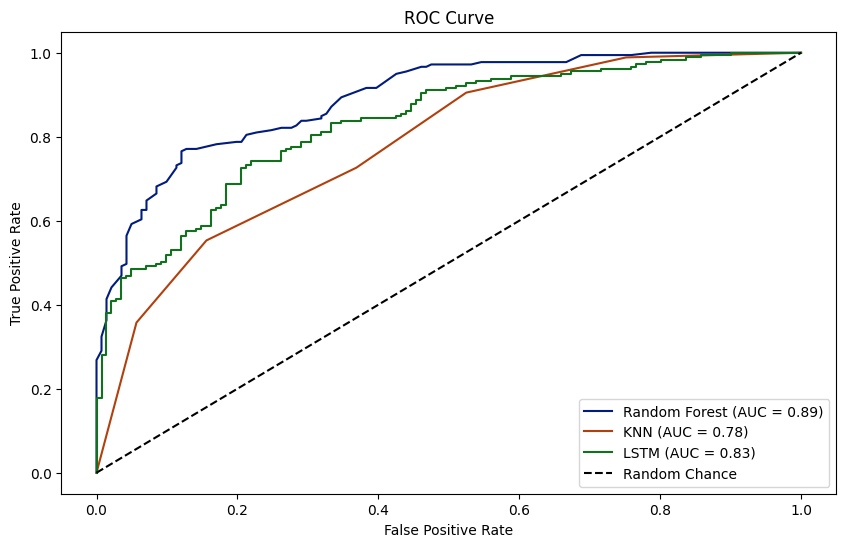

Discussion:
Random Forest performs the best due to its ensemble nature, reducing overfitting and handling complex interactions.


In [93]:
# features and values are seperated. If quality is greater than  then it is to be taken as good quality wine
X = vino.iloc[:, :-1].values  # Features
y = (vino.iloc[:, -1].values > 5).astype(int)

# Normalize the features
scaler = MinMaxScaler()
X = scaler.fit_transform(X)

# Calculate metrics
def metricCalc(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    TPR = tp / (tp + fn) if (tp + fn) > 0 else 0
    TNR = tn / (tn + fp) if (tn + fp) > 0 else 0
    FPR = fp / (fp + tn) if (fp + tn) > 0 else 0
    FNR = fn / (fn + tp) if (fn + tp) > 0 else 0
    Precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    F1Score = 2 * (Precision * TPR) / (Precision + TPR) if (Precision + TPR) > 0 else 0
    errorRate = (fp + fn) / (tp + tn + fp + fn)
    BACC = (TPR + TNR) / 2
    TSS = TPR - FPR
    HSS = 2 * (tp * tn - fp * fn) / ((tp + fn) * (fn + tn) + (tp + fp) * (fp + tn)) if (tp + fn) * (fn + tn) + (tp + fp) * (fp + tn) > 0 else 0
    return {
        'TP': tp, 'TN': tn, 'FP': fp, 'FN': fn,
        'TPR': TPR, 'TNR': TNR, 'FPR': FPR, 'FNR': FNR,
        'Precision': Precision, 'F1Score': F1Score,
        'errorRate': errorRate, 'BACC': BACC, 'TSS': TSS, 'HSS': HSS
    }

# 10 fold Cross-validation
def validation(model, mtype, X, y, n_splits=10):
    kf = KFold(n_splits =n_splits , shuffle=True, random_state=42)
    metrics_list = []

    for train_idx, test_idx in kf.split(X):
        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]

        if mtype == 'LSTM':
            X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
            X_test = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))
            model.fit(X_train, y_train, epochs=10, batch_size=32, verbose=0)
            y_pred = (model.predict(X_test) > 0.5).astype(int)
        else:
            model.fit(X_train, y_train)
            y_pred = model.predict(X_test)

        metrics = metricCalc(y_test, y_pred)
        metrics_list.append(metrics)

    avg_metrics = {key: np.mean([m[key] for m in metrics_list]) for key in metrics_list[0]}
    return metrics_list, avg_metrics

# Create models
def lstmMaker(input_shape):
    model = Sequential()
    model.add(LSTM(50, input_shape=input_shape, activation='tanh'))
    model.add(Dense(1, activation='sigmoid'))
    model.compile(optimizer=Adam(learning_rate=0.001), loss='binary_crossentropy', metrics=['accuracy'])
    return model

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
knn_model = KNeighborsClassifier(n_neighbors=5)
lstm_model = lstmMaker((X.shape[1], 1))

rf_metrics, rf_avg = validation(rf_model, 'RandomForest', X, y)
knn_metrics, knn_avg = validation(knn_model, 'KNN', X, y)
lstm_metrics, lstm_avg = validation(lstm_model, 'LSTM', X, y)
#tabulated results
def tableResults(metrics_list, avg_metrics):
    df = pd.DataFrame(metrics_list)
    avg_row = pd.DataFrame(avg_metrics, index=["Average"])
    return pd.concat([df, avg_row])

rf_results = tableResults(rf_metrics, rf_avg)
knn_results = tableResults(knn_metrics, knn_avg)
lstm_results = tableResults(lstm_metrics, lstm_avg)

print("Random Forest Metrics:")
display(rf_results)

print("KNN Metrics:")
display(knn_results)

print("LSTM Metrics:")
display(lstm_results)

def rocCurve(models, model_names, X, y):
    plt.figure(figsize=(10, 6))
    for model, name in zip(models, model_names):
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

        if name == "LSTM":
            X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
            X_test = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))
            model.fit(X_train, y_train, epochs=10, batch_size=32, verbose=0)
            y_proba = model.predict(X_test).ravel()
        else:
            model.fit(X_train, y_train)
            y_proba = model.predict_proba(X_test)[:, 1]

        fpr, tpr, _ = roc_curve(y_test, y_proba)
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc:.2f})")

    plt.plot([0, 1], [0, 1], 'k--', label="Random Chance")
    plt.title("ROC Curve")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.legend(loc="lower right")
    plt.show()

rocCurve([rf_model, knn_model, lstm_model], ["Random Forest", "KNN", "LSTM"], X, y)

# Discussion
print("Discussion:")
if rf_avg["F1Score"] > knn_avg["F1Score"] and rf_avg["F1Score"] > lstm_avg["F1Score"]:
    print("Random Forest performs the best due to its ensemble nature, reducing overfitting and handling complex interactions.")
elif knn_avg["F1Score"] > rf_avg["F1Score"] and knn_avg["F1Score"] > lstm_avg["F1Score"]:
    print("KNN performs the best as the dataset's local structure suits proximity-based methods.")
else:
    print("LSTM performs the best, leveraging temporal and complex feature relationships due to its deep learning architecture.")
